In [2]:
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import load_iris
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from IPython.display import Image
import math
import matplotlib.pyplot as plt
import matplotlib
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Reproducibility
np.random.seed(42)

def points_in_circle(radius, n_points):
    angles = np.linspace(0, 2 * math.pi, n_points)
    
    x = radius * np.cos(angles) + np.random.normal(0, 30, n_points)
    y = radius * np.sin(angles) + np.random.normal(0, 30, n_points)
    
    return np.column_stack((x, y))

circle_outer = points_in_circle(500, 1000)
circle_middle = points_in_circle(300, 700)
circle_inner = points_in_circle(100, 300)

noise = np.random.randint(-600, 600, size=(300, 2))

data = np.vstack([
    circle_outer,
    circle_middle,
    circle_inner,
    noise
])

df = pd.DataFrame(data, columns=["x", "y"])


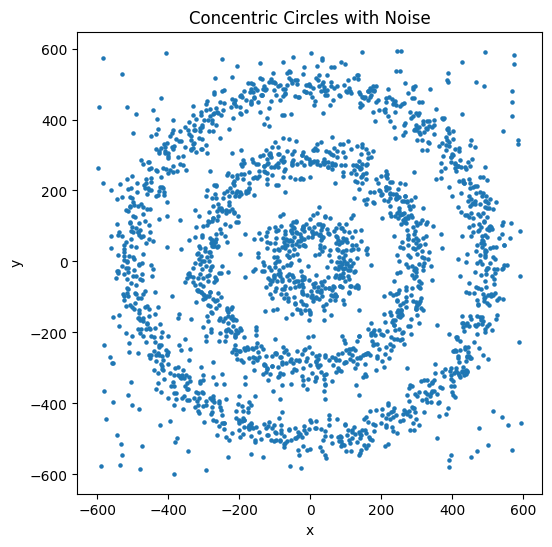

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(df["x"], df["y"], s=5)
plt.title("Concentric Circles with Noise")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()


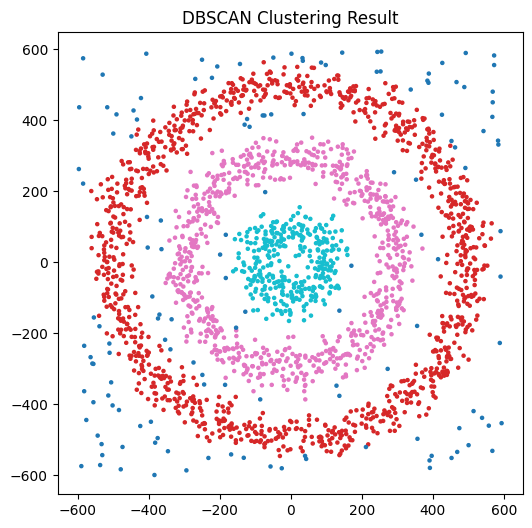

In [7]:
from sklearn.cluster import DBSCAN

X = df[["x", "y"]].values

dbscan = DBSCAN(
    eps=40,          # neighborhood radius
    min_samples=10,  # MinPts
    metric="euclidean"
)

dbscan.fit(X)

df["cluster"] = dbscan.labels_

plt.figure(figsize=(6,6))
plt.scatter(df["x"], df["y"], c=df["cluster"], cmap="tab10", s=5)
plt.title("DBSCAN Clustering Result")
plt.axis("equal")
plt.show()


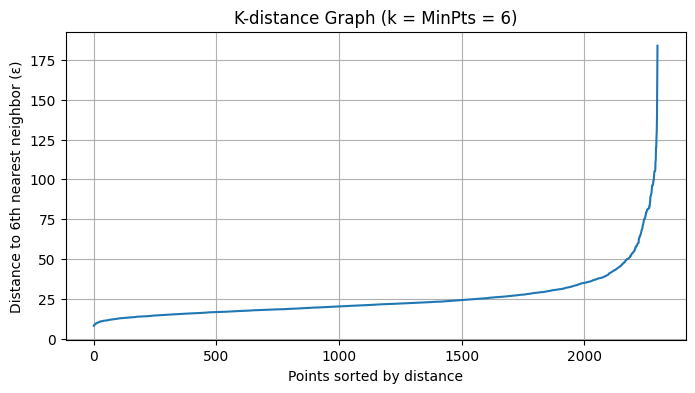

In [8]:
from sklearn.neighbors import NearestNeighbors

X = df[["x", "y"]].values

k = 6

neigh = NearestNeighbors(n_neighbors=k)
neigh.fit(X)

distances, indices = neigh.kneighbors(X)
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title("K-distance Graph (k = MinPts = 6)")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 6th nearest neighbor (ε)")
plt.grid(True)
plt.show()


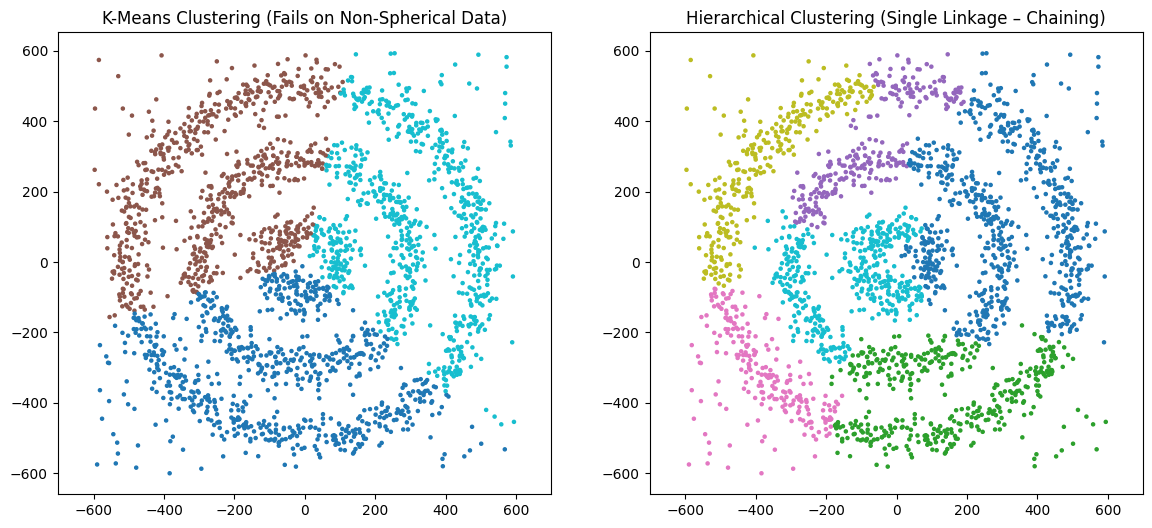

In [11]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering

X = df[["x", "y"]].values

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

hierarchical = AgglomerativeClustering(
    n_clusters=6,
    linkage="complete"
)
hier_labels = hierarchical.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means plot
axes[0].scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap="tab10", s=5)
axes[0].set_title("K-Means Clustering (Fails on Non-Spherical Data)")
axes[0].axis("equal")

# Hierarchical plot
axes[1].scatter(X[:, 0], X[:, 1], c=hier_labels, cmap="tab10", s=5)
axes[1].set_title("Hierarchical Clustering (Single Linkage – Chaining)")
axes[1].axis("equal")

plt.show()
